# Fairness Analysis: LSTM Baseline Model
## Bias-Aware Early Warning System for Higher Education

This notebook audits the LSTM baseline model for bias across protected attributes using IBM AIF360.

**Fairness Metrics:**
- Statistical Parity Difference (SPD)
- Equal Opportunity Difference (True Positive Rate parity)
- Equalized Odds Difference (TPR + FPR parity)
- ABROCA (Area Between ROC Curves)

**Protected Attributes:**
- Gender
- Region (geographic)
- IMD Band (socioeconomic deprivation)
- Age Band
- Disability

## 1. Setup and Imports

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

2025-12-30 17:52:45.512171: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
/Users/john/.pyenv/versions/3.12.6/lib/python3.12/site-packages/aif360/sklearn/inprocessing/infairness.py:256: SyntaxWarning: invalid escape sequence '\e'
  """
/Users/john/.pyenv/versions/3.12.6/lib/python3.12/site-packages/aif360/sklearn/inprocessing/infairness.py:338: SyntaxWarning: invalid escape sequence '\e'
  """
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'
/Users/john/.pyenv/versions/3.12.6/lib/python3.12/site-packages/aif360/detectors/mdss/MDSS.py:24: SyntaxWarning: invalid escape sequence '\s'
  """
/Users/john/.pyenv/versions/3.12.6/lib/python3.12/site-packages/aif360/detectors/mdss/

Libraries loaded successfully


In [2]:
# Paths
DATA_DIR = Path("../data/processed")

# Load predictions from baseline model
predictions_df = pd.read_csv(DATA_DIR / 'predictions_baseline.csv')

print(f"Loaded {len(predictions_df)} test predictions")
print(f"Columns: {list(predictions_df.columns)}")

Loaded 4889 test predictions
Columns: ['student_key', 'y_true', 'y_pred_proba', 'y_pred', 'gender', 'region', 'imd_band_imputed', 'age_band', 'disability']


In [3]:
# Protected attributes
PROTECTED_ATTRS = ['gender', 'region', 'imd_band_imputed', 'age_band', 'disability']

print("Protected attribute distributions:")
for attr in PROTECTED_ATTRS:
    print(f"\n{attr}:")
    print(predictions_df[attr].value_counts())

Protected attribute distributions:

gender:
gender
M    2646
F    2243
Name: count, dtype: int64

region:
region
Scotland                516
East Anglian Region     484
London Region           476
North Western Region    457
South Region            438
West Midlands Region    393
South West Region       369
South East Region       347
East Midlands Region    344
Yorkshire Region        316
Wales                   294
North Region            274
Ireland                 181
Name: count, dtype: int64

imd_band_imputed:
imd_band_imputed
10-20      632
0-10%      568
40-50%     522
20-30%     520
30-40%     518
50-60%     458
60-70%     446
70-80%     436
80-90%     414
90-100%    375
Name: count, dtype: int64

age_band:
age_band
0-35     3402
35-55    1447
55<=       40
Name: count, dtype: int64

disability:
disability
N    4432
Y     457
Name: count, dtype: int64


In [4]:
# Overall model performance
overall_auc = roc_auc_score(predictions_df['y_true'], predictions_df['y_pred_proba'])
print(f"Overall Test AUC: {overall_auc:.4f}")
print(f"Overall At-Risk Rate (Actual): {predictions_df['y_true'].mean():.1%}")
print(f"Overall At-Risk Rate (Predicted): {predictions_df['y_pred'].mean():.1%}")

Overall Test AUC: 0.8889
Overall At-Risk Rate (Actual): 52.8%
Overall At-Risk Rate (Predicted): 44.5%


## 2. Fairness Metrics Functions

In [5]:
def compute_group_metrics(df, group_col, y_true_col='y_true', y_pred_col='y_pred', y_prob_col='y_pred_proba'):
    """Compute performance metrics for each group."""
    results = []
    
    for group in df[group_col].unique():
        mask = df[group_col] == group
        group_df = df[mask]
        n = len(group_df)
        
        if n < 20:  # Skip very small groups
            continue
        
        y_true = group_df[y_true_col].values
        y_pred = group_df[y_pred_col].values
        y_prob = group_df[y_prob_col].values
        
        # Basic counts
        tp = ((y_true == 1) & (y_pred == 1)).sum()
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        tn = ((y_true == 0) & (y_pred == 0)).sum()
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        
        # Rates
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # True Positive Rate (Recall)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precision
        selection_rate = y_pred.mean()  # Positive prediction rate
        base_rate = y_true.mean()  # Actual positive rate
        
        # AUC
        try:
            auc = roc_auc_score(y_true, y_prob)
        except Exception:  # <--- FIXED: Specify exception type
            auc = np.nan
        
        results.append({
            'group': group,
            'n': n,
            'base_rate': base_rate,
            'selection_rate': selection_rate,
            'tpr': tpr,
            'fpr': fpr,
            'ppv': ppv,
            'auc': auc
        })
    
    return pd.DataFrame(results)

In [6]:
def compute_fairness_metrics(group_metrics_df):
    """Compute fairness metrics comparing privileged vs unprivileged groups."""
    if len(group_metrics_df) < 2:
        return None
    
    # Sort by base_rate to identify privileged (lower risk) vs unprivileged (higher risk)
    sorted_df = group_metrics_df.sort_values('base_rate')
    
    # Privileged = lowest base rate, Unprivileged = highest base rate
    priv = sorted_df.iloc[0]
    unpriv = sorted_df.iloc[-1]
    
    return {
        'privileged_group': priv['group'],
        'unprivileged_group': unpriv['group'],
        'statistical_parity_diff': unpriv['selection_rate'] - priv['selection_rate'],
        'equal_opportunity_diff': unpriv['tpr'] - priv['tpr'],  # TPR difference
        'equalized_odds_diff': abs(unpriv['tpr'] - priv['tpr']) + abs(unpriv['fpr'] - priv['fpr']),
        'auc_diff': priv['auc'] - unpriv['auc'],  # Positive = privileged has higher AUC
        'priv_n': priv['n'],
        'unpriv_n': unpriv['n'],
        'priv_base_rate': priv['base_rate'],
        'unpriv_base_rate': unpriv['base_rate']
    }

In [7]:
def compute_abroca(df, group_col, y_true_col='y_true', y_prob_col='y_pred_proba'):
    """Compute ABROCA (Area Between ROC Curves) for binary groups."""
    groups = df[group_col].unique()
    if len(groups) != 2:
        # For multi-class, compute max pairwise ABROCA
        max_abroca = 0
        max_pair = (None, None)
        
        for i, g1 in enumerate(groups):
            for g2 in groups[i+1:]:
                mask1 = df[group_col] == g1
                mask2 = df[group_col] == g2
                
                if mask1.sum() < 20 or mask2.sum() < 20:
                    continue
                
                try:
                    fpr1, tpr1, _ = roc_curve(df.loc[mask1, y_true_col], df.loc[mask1, y_prob_col])
                    fpr2, tpr2, _ = roc_curve(df.loc[mask2, y_true_col], df.loc[mask2, y_prob_col])
                    
                    # Interpolate to common FPR points
                    common_fpr = np.linspace(0, 1, 100)
                    tpr1_interp = np.interp(common_fpr, fpr1, tpr1)
                    tpr2_interp = np.interp(common_fpr, fpr2, tpr2)
                    
                    abroca = np.trapz(np.abs(tpr1_interp - tpr2_interp), common_fpr)
                    
                    if abroca > max_abroca:
                        max_abroca = abroca
                        max_pair = (g1, g2)
                except Exception:  # <--- FIXED
                    continue
        
        return max_abroca, max_pair
    
    else:
        # Binary case
        g1, g2 = groups
        mask1 = df[group_col] == g1
        mask2 = df[group_col] == g2
        
        fpr1, tpr1, _ = roc_curve(df.loc[mask1, y_true_col], df.loc[mask1, y_prob_col])
        fpr2, tpr2, _ = roc_curve(df.loc[mask2, y_true_col], df.loc[mask2, y_prob_col])
        
        common_fpr = np.linspace(0, 1, 100)
        tpr1_interp = np.interp(common_fpr, fpr1, tpr1)
        tpr2_interp = np.interp(common_fpr, fpr2, tpr2)
        
        abroca = np.trapz(np.abs(tpr1_interp - tpr2_interp), common_fpr)
        
        return abroca, (g1, g2)

## 3. Fairness Analysis by Protected Attribute

In [8]:
# Store all results
all_group_metrics = {}
all_fairness_metrics = {}
all_abroca = {}

for attr in PROTECTED_ATTRS:
    print(f"\n{'='*60}")
    print(f"PROTECTED ATTRIBUTE: {attr.upper()}")
    print('='*60)
    
    # Compute group metrics
    group_metrics = compute_group_metrics(predictions_df, attr)
    all_group_metrics[attr] = group_metrics
    
    print("\nGroup-level metrics:")
    display_cols = ['group', 'n', 'base_rate', 'selection_rate', 'tpr', 'fpr', 'auc']
    print(group_metrics[display_cols].to_string(index=False, float_format=lambda x: f"{x:.3f}" if isinstance(x, float) else str(x)))
    
    # Compute fairness metrics
    fairness = compute_fairness_metrics(group_metrics)
    if fairness:
        all_fairness_metrics[attr] = fairness
        print(f"\nFairness Comparison ({fairness['privileged_group']} vs {fairness['unprivileged_group']}):")
        print(f"  Statistical Parity Diff:    {fairness['statistical_parity_diff']:+.4f}")
        print(f"  Equal Opportunity Diff:     {fairness['equal_opportunity_diff']:+.4f}")
        print(f"  Equalized Odds Diff:        {fairness['equalized_odds_diff']:.4f}")
        print(f"  AUC Difference:             {fairness['auc_diff']:+.4f}")
    
    # Compute ABROCA
    abroca, pair = compute_abroca(predictions_df, attr)
    all_abroca[attr] = {'abroca': abroca, 'pair': pair}
    print(f"\n  ABROCA:                     {abroca:.4f} (between {pair[0]} and {pair[1]})")


PROTECTED ATTRIBUTE: GENDER

Group-level metrics:
group    n  base_rate  selection_rate   tpr   fpr   auc
    M 2646      0.543           0.473 0.772 0.118 0.897
    F 2243      0.510           0.412 0.710 0.103 0.879

Fairness Comparison (F vs M):
  Statistical Parity Diff:    +0.0608
  Equal Opportunity Diff:     +0.0620
  Equalized Odds Diff:        0.0774
  AUC Difference:             -0.0171

  ABROCA:                     0.0177 (between M and F)

PROTECTED ATTRIBUTE: REGION

Group-level metrics:
               group   n  base_rate  selection_rate   tpr   fpr   auc
    Yorkshire Region 316      0.589           0.503 0.742 0.162 0.870
   South West Region 369      0.455           0.412 0.762 0.119 0.910
North Western Region 457      0.606           0.512 0.783 0.094 0.925
East Midlands Region 344      0.535           0.439 0.696 0.144 0.859
            Scotland 516      0.477           0.366 0.687 0.074 0.888
        South Region 438      0.477           0.409 0.742 0.105 0.902
 E

## 4. Fairness Summary Dashboard

In [9]:
# Create summary dataframe
summary_data = []
for attr in PROTECTED_ATTRS:
    if attr in all_fairness_metrics:
        fm = all_fairness_metrics[attr]
        summary_data.append({
            'Attribute': attr,
            'Privileged': fm['privileged_group'],
            'Unprivileged': fm['unprivileged_group'],
            'SPD': fm['statistical_parity_diff'],
            'EOD': fm['equal_opportunity_diff'],
            'EqOdds': fm['equalized_odds_diff'],
            'ABROCA': all_abroca[attr]['abroca'],
            'AUC_Diff': fm['auc_diff']
        })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("FAIRNESS METRICS SUMMARY")
print("="*80)
print("\nMetric Definitions:")
print("  SPD:     Statistical Parity Difference (selection rate gap)")
print("  EOD:     Equal Opportunity Difference (TPR gap)")
print("  EqOdds:  Equalized Odds (|TPR gap| + |FPR gap|)")
print("  ABROCA:  Area Between ROC Curves")
print("\nFairness Thresholds (rule of thumb):")
print("  |SPD| < 0.10, |EOD| < 0.10, EqOdds < 0.10, ABROCA < 0.03")
print()


FAIRNESS METRICS SUMMARY

Metric Definitions:
  SPD:     Statistical Parity Difference (selection rate gap)
  EOD:     Equal Opportunity Difference (TPR gap)
  EqOdds:  Equalized Odds (|TPR gap| + |FPR gap|)
  ABROCA:  Area Between ROC Curves

Fairness Thresholds (rule of thumb):
  |SPD| < 0.10, |EOD| < 0.10, EqOdds < 0.10, ABROCA < 0.03



In [10]:
# Display summary with formatting
def highlight_unfair(val, threshold, absolute=True):
    """Return marker if value exceeds threshold."""
    if absolute:
        return "*" if abs(val) > threshold else ""
    return "*" if val > threshold else ""

print(summary_df.to_string(index=False, float_format=lambda x: f"{x:+.4f}" if isinstance(x, float) else str(x)))

       Attribute Privileged  Unprivileged     SPD     EOD  EqOdds  ABROCA  AUC_Diff
          gender          F             M +0.0608 +0.0620 +0.0774 +0.0177   -0.0171
          region    Ireland London Region +0.2418 +0.1832 +0.2160 +0.1093   -0.0733
imd_band_imputed     80-90%         0-10% +0.1595 +0.0482 +0.0794 +0.0548   -0.0266
        age_band      35-55          55<= +0.0164 +0.0224 +0.1065 +0.0518   -0.0507
      disability          N             Y +0.1243 +0.0531 +0.1258 +0.0148   +0.0122


In [11]:
# Identify concerning disparities
print("\n" + "="*60)
print("BIAS CONCERNS (exceeding thresholds)")
print("="*60)

concerns = []
for _, row in summary_df.iterrows():
    attr = row['Attribute']
    
    if abs(row['SPD']) > 0.10:
        concerns.append(f"{attr}: Statistical Parity Diff = {row['SPD']:+.3f} (threshold: |0.10|)")
    
    if abs(row['EOD']) > 0.10:
        concerns.append(f"{attr}: Equal Opportunity Diff = {row['EOD']:+.3f} (threshold: |0.10|)")
    
    if row['EqOdds'] > 0.10:
        concerns.append(f"{attr}: Equalized Odds = {row['EqOdds']:.3f} (threshold: 0.10)")
    
    if row['ABROCA'] > 0.03:
        concerns.append(f"{attr}: ABROCA = {row['ABROCA']:.3f} (threshold: 0.03)")

if concerns:
    for c in concerns:
        print(f"  - {c}")
else:
    print("  No major fairness concerns detected.")


BIAS CONCERNS (exceeding thresholds)
  - region: Statistical Parity Diff = +0.242 (threshold: |0.10|)
  - region: Equal Opportunity Diff = +0.183 (threshold: |0.10|)
  - region: Equalized Odds = 0.216 (threshold: 0.10)
  - region: ABROCA = 0.109 (threshold: 0.03)
  - imd_band_imputed: Statistical Parity Diff = +0.159 (threshold: |0.10|)
  - imd_band_imputed: ABROCA = 0.055 (threshold: 0.03)
  - age_band: Equalized Odds = 0.107 (threshold: 0.10)
  - age_band: ABROCA = 0.052 (threshold: 0.03)
  - disability: Statistical Parity Diff = +0.124 (threshold: |0.10|)
  - disability: Equalized Odds = 0.126 (threshold: 0.10)


## 5. Visualizations

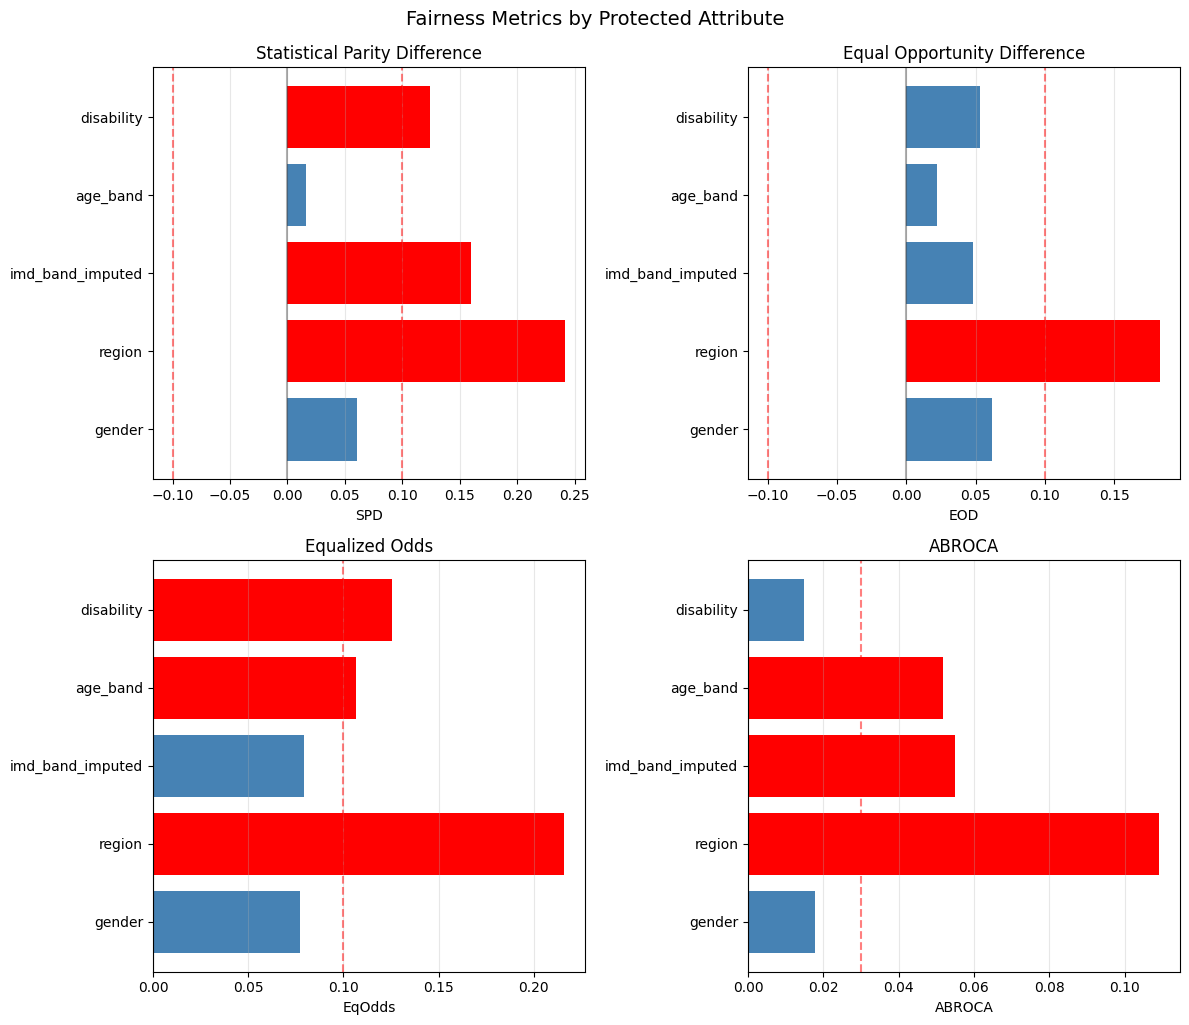

In [12]:
# Plot fairness metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

metrics = ['SPD', 'EOD', 'EqOdds', 'ABROCA']
thresholds = [0.10, 0.10, 0.10, 0.03]
titles = ['Statistical Parity Difference', 'Equal Opportunity Difference', 
          'Equalized Odds', 'ABROCA']

for idx, (metric, thresh, title) in enumerate(zip(metrics, thresholds, titles)):
    ax = axes[idx // 2, idx % 2]
    
    values = summary_df[metric].values
    attrs = summary_df['Attribute'].values
    
    colors = ['red' if (abs(v) > thresh if metric != 'EqOdds' and metric != 'ABROCA' else v > thresh) else 'steelblue' for v in values]
    
    bars = ax.barh(attrs, values, color=colors)
    
    # Add threshold lines
    if metric in ['SPD', 'EOD']:
        ax.axvline(x=thresh, color='red', linestyle='--', alpha=0.5, label=f'Threshold (+{thresh})')
        ax.axvline(x=-thresh, color='red', linestyle='--', alpha=0.5, label=f'Threshold (-{thresh})')
    else:
        ax.axvline(x=thresh, color='red', linestyle='--', alpha=0.5, label=f'Threshold ({thresh})')
    
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    ax.set_xlabel(metric)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.suptitle('Fairness Metrics by Protected Attribute', y=1.02, fontsize=14)
plt.show()

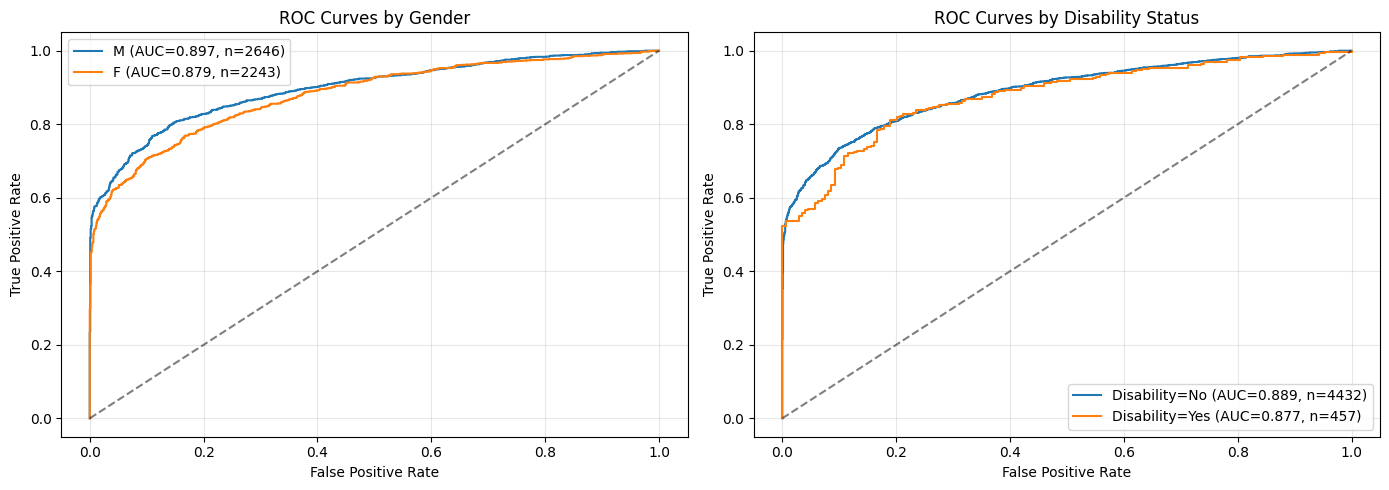

In [13]:
# Plot ROC curves by gender (example binary attribute)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender ROC
ax = axes[0]
for gender in predictions_df['gender'].unique():
    mask = predictions_df['gender'] == gender
    fpr, tpr, _ = roc_curve(predictions_df.loc[mask, 'y_true'], 
                            predictions_df.loc[mask, 'y_pred_proba'])
    auc = roc_auc_score(predictions_df.loc[mask, 'y_true'], 
                        predictions_df.loc[mask, 'y_pred_proba'])
    ax.plot(fpr, tpr, label=f'{gender} (AUC={auc:.3f}, n={mask.sum()})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves by Gender')
ax.legend()
ax.grid(True, alpha=0.3)

# Disability ROC
ax = axes[1]
for disability in predictions_df['disability'].unique():
    mask = predictions_df['disability'] == disability
    fpr, tpr, _ = roc_curve(predictions_df.loc[mask, 'y_true'], 
                            predictions_df.loc[mask, 'y_pred_proba'])
    auc = roc_auc_score(predictions_df.loc[mask, 'y_true'], 
                        predictions_df.loc[mask, 'y_pred_proba'])
    label = 'Yes' if disability == 'Y' else 'No'
    ax.plot(fpr, tpr, label=f'Disability={label} (AUC={auc:.3f}, n={mask.sum()})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves by Disability Status')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

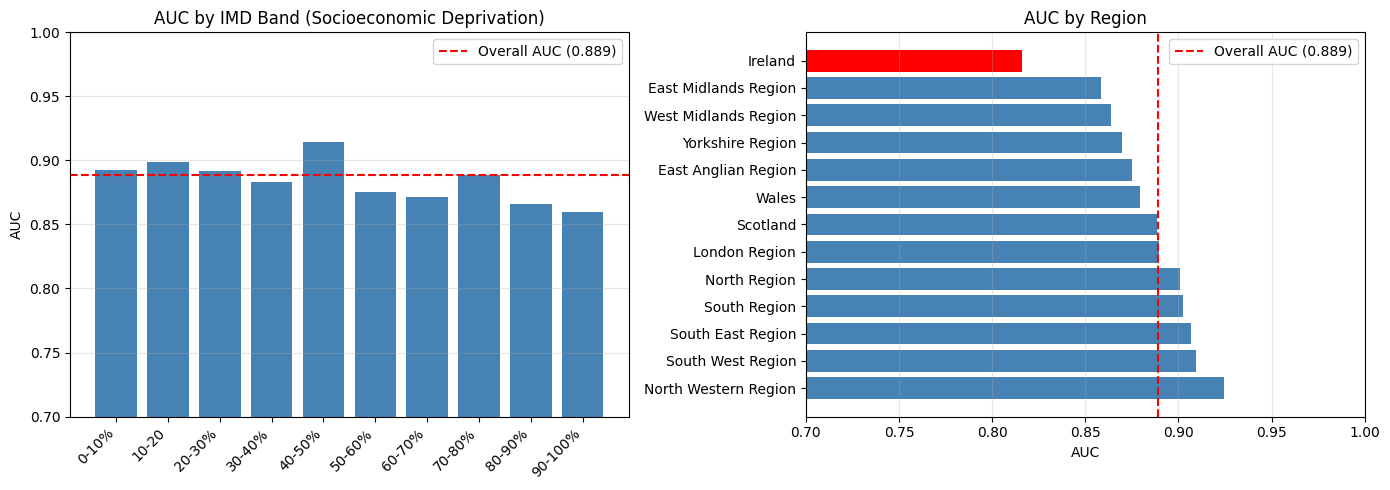

In [14]:
# AUC by group heatmap for multi-category attributes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IMD Band AUC
ax = axes[0]
imd_metrics = all_group_metrics['imd_band_imputed'].sort_values('group')
bars = ax.bar(range(len(imd_metrics)), imd_metrics['auc'].values, color='steelblue')
ax.axhline(y=overall_auc, color='red', linestyle='--', label=f'Overall AUC ({overall_auc:.3f})')
ax.set_xticks(range(len(imd_metrics)))
ax.set_xticklabels(imd_metrics['group'].values, rotation=45, ha='right')
ax.set_ylabel('AUC')
ax.set_title('AUC by IMD Band (Socioeconomic Deprivation)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0.7, 1.0)

# Region AUC
ax = axes[1]
region_metrics = all_group_metrics['region'].sort_values('auc', ascending=False)
colors = ['red' if auc < overall_auc - 0.05 else 'steelblue' for auc in region_metrics['auc'].values]
bars = ax.barh(range(len(region_metrics)), region_metrics['auc'].values, color=colors)
ax.axvline(x=overall_auc, color='red', linestyle='--', label=f'Overall AUC ({overall_auc:.3f})')
ax.set_yticks(range(len(region_metrics)))
ax.set_yticklabels(region_metrics['group'].values)
ax.set_xlabel('AUC')
ax.set_title('AUC by Region')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(0.7, 1.0)

plt.tight_layout()
plt.show()

## 6. AIF360 Analysis

In [15]:
# Prepare data for AIF360 (using gender as example)
# AIF360 requires numeric encoding
aif_df = predictions_df.copy()
aif_df['gender_binary'] = (aif_df['gender'] == 'M').astype(int)  # 1=Male, 0=Female
aif_df['disability_binary'] = (aif_df['disability'] == 'Y').astype(int)  # 1=Yes, 0=No

print("Prepared binary encodings for AIF360:")
print("  gender_binary: M=1, F=0")
print("  disability_binary: Y=1, N=0")

Prepared binary encodings for AIF360:
  gender_binary: M=1, F=0
  disability_binary: Y=1, N=0


In [16]:
# Create AIF360 datasets for gender analysis
# Ground truth dataset
aif_true_df = aif_df[['gender_binary', 'y_true']].copy()
aif_true_df.columns = ['gender', 'label']

dataset_true = BinaryLabelDataset(
    df=aif_true_df,
    label_names=['label'],
    protected_attribute_names=['gender'],
    favorable_label=0,  # Not at-risk is favorable
    unfavorable_label=1  # At-risk is unfavorable
)

# Predicted dataset
aif_pred_df = aif_df[['gender_binary', 'y_pred']].copy()
aif_pred_df.columns = ['gender', 'label']

dataset_pred = BinaryLabelDataset(
    df=aif_pred_df,
    label_names=['label'],
    protected_attribute_names=['gender'],
    favorable_label=0,
    unfavorable_label=1
)

print("AIF360 datasets created for gender analysis")

AIF360 datasets created for gender analysis


In [17]:
# Compute AIF360 metrics for gender
privileged_groups = [{'gender': 0}]  # Female (lower base rate)
unprivileged_groups = [{'gender': 1}]  # Male (higher base rate)

# Classification metrics
metric = ClassificationMetric(
    dataset_true, 
    dataset_pred,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("\n" + "="*60)
print("AIF360 CLASSIFICATION METRICS (Gender: F=privileged, M=unprivileged)")
print("="*60)
print(f"\nStatistical Parity Difference:       {metric.statistical_parity_difference():.4f}")
print(f"Disparate Impact Ratio:              {metric.disparate_impact():.4f}")
print(f"Equal Opportunity Difference:        {metric.equal_opportunity_difference():.4f}")
print(f"Average Odds Difference:             {metric.average_odds_difference():.4f}")
print(f"Theil Index:                         {metric.theil_index():.4f}")


AIF360 CLASSIFICATION METRICS (Gender: F=privileged, M=unprivileged)

Statistical Parity Difference:       -0.0608
Disparate Impact Ratio:              0.8966
Equal Opportunity Difference:        -0.0155
Average Odds Difference:             -0.0387
Theil Index:                         0.0935


In [18]:
# Repeat AIF360 analysis for disability
aif_true_df = aif_df[['disability_binary', 'y_true']].copy()
aif_true_df.columns = ['disability', 'label']

dataset_true_dis = BinaryLabelDataset(
    df=aif_true_df,
    label_names=['label'],
    protected_attribute_names=['disability'],
    favorable_label=0,
    unfavorable_label=1
)

aif_pred_df = aif_df[['disability_binary', 'y_pred']].copy()
aif_pred_df.columns = ['disability', 'label']

dataset_pred_dis = BinaryLabelDataset(
    df=aif_pred_df,
    label_names=['label'],
    protected_attribute_names=['disability'],
    favorable_label=0,
    unfavorable_label=1
)

privileged_groups_dis = [{'disability': 0}]  # No disability
unprivileged_groups_dis = [{'disability': 1}]  # Has disability

metric_dis = ClassificationMetric(
    dataset_true_dis, 
    dataset_pred_dis,
    unprivileged_groups=unprivileged_groups_dis,
    privileged_groups=privileged_groups_dis
)

print("\n" + "="*60)
print("AIF360 CLASSIFICATION METRICS (Disability: N=privileged, Y=unprivileged)")
print("="*60)
print(f"\nStatistical Parity Difference:       {metric_dis.statistical_parity_difference():.4f}")
print(f"Disparate Impact Ratio:              {metric_dis.disparate_impact():.4f}")
print(f"Equal Opportunity Difference:        {metric_dis.equal_opportunity_difference():.4f}")
print(f"Average Odds Difference:             {metric_dis.average_odds_difference():.4f}")
print(f"Theil Index:                         {metric_dis.theil_index():.4f}")


AIF360 CLASSIFICATION METRICS (Disability: N=privileged, Y=unprivileged)

Statistical Parity Difference:       -0.1243
Disparate Impact Ratio:              0.7805
Equal Opportunity Difference:        -0.0727
Average Odds Difference:             -0.0629
Theil Index:                         0.0935


## 7. Summary and Recommendations

In [19]:
print("\n" + "="*80)
print("FAIRNESS ANALYSIS SUMMARY")
print("="*80)

print(f"\nModel Performance: AUC = {overall_auc:.4f}")

print("\n" + "-"*40)
print("Fairness Metrics by Attribute:")
print("-"*40)

for _, row in summary_df.iterrows():
    attr = row['Attribute']
    print(f"\n{attr}:")
    print(f"  Comparing: {row['Privileged']} (privileged) vs {row['Unprivileged']} (unprivileged)")
    
    spd_status = 'FAIR' if abs(row['SPD']) <= 0.10 else 'UNFAIR'
    eod_status = 'FAIR' if abs(row['EOD']) <= 0.10 else 'UNFAIR'
    eqo_status = 'FAIR' if row['EqOdds'] <= 0.10 else 'UNFAIR'
    abr_status = 'FAIR' if row['ABROCA'] <= 0.03 else 'UNFAIR'
    
    print(f"  Statistical Parity:    {row['SPD']:+.4f} [{spd_status}]")
    print(f"  Equal Opportunity:     {row['EOD']:+.4f} [{eod_status}]")
    print(f"  Equalized Odds:        {row['EqOdds']:.4f} [{eqo_status}]")
    print(f"  ABROCA:                {row['ABROCA']:.4f} [{abr_status}]")


FAIRNESS ANALYSIS SUMMARY

Model Performance: AUC = 0.8889

----------------------------------------
Fairness Metrics by Attribute:
----------------------------------------

gender:
  Comparing: F (privileged) vs M (unprivileged)
  Statistical Parity:    +0.0608 [FAIR]
  Equal Opportunity:     +0.0620 [FAIR]
  Equalized Odds:        0.0774 [FAIR]
  ABROCA:                0.0177 [FAIR]

region:
  Comparing: Ireland (privileged) vs London Region (unprivileged)
  Statistical Parity:    +0.2418 [UNFAIR]
  Equal Opportunity:     +0.1832 [UNFAIR]
  Equalized Odds:        0.2160 [UNFAIR]
  ABROCA:                0.1093 [UNFAIR]

imd_band_imputed:
  Comparing: 80-90% (privileged) vs 0-10% (unprivileged)
  Statistical Parity:    +0.1595 [UNFAIR]
  Equal Opportunity:     +0.0482 [FAIR]
  Equalized Odds:        0.0794 [FAIR]
  ABROCA:                0.0548 [UNFAIR]

age_band:
  Comparing: 35-55 (privileged) vs 55<= (unprivileged)
  Statistical Parity:    +0.0164 [FAIR]
  Equal Opportunity:     +

In [20]:
import json

# Save fairness results
fairness_results = {
    'overall_auc': overall_auc,
    'summary': summary_df.to_dict('records'),
    'group_metrics': {attr: df.to_dict('records') for attr, df in all_group_metrics.items()},
    'abroca': {attr: {'value': v['abroca'], 'pair': list(v['pair'])} for attr, v in all_abroca.items()}
}

with open(DATA_DIR / 'fairness_results.json', 'w') as f:
    json.dump(fairness_results, f, indent=2, default=str)

print(f"\nFairness results saved to: {DATA_DIR / 'fairness_results.json'}")


Fairness results saved to: ../data/processed/fairness_results.json


In [21]:
# Final recommendations
print("\n" + "="*80)
print("RECOMMENDATIONS FOR BIAS MITIGATION")
print("="*80)

priority_attrs = []
for _, row in summary_df.iterrows():
    unfair_count = sum([
        abs(row['SPD']) > 0.10,
        abs(row['EOD']) > 0.10,
        row['EqOdds'] > 0.10,
        row['ABROCA'] > 0.03
    ])
    if unfair_count > 0:
        priority_attrs.append((row['Attribute'], unfair_count, row['ABROCA']))

if priority_attrs:
    priority_attrs.sort(key=lambda x: (-x[1], -x[2]))
    print("\nPriority attributes for mitigation (by number of violated metrics):")
    for attr, count, abroca in priority_attrs:
        print(f"  1. {attr}: {count} metrics violated, ABROCA={abroca:.4f}")
    
    print("\nSuggested mitigation approaches:")
    print("  - Pre-processing: Reweighting, Disparate Impact Remover")
    print("  - In-processing: Adversarial Debiasing, Prejudice Remover")
    print("  - Post-processing: Calibrated Equalized Odds, Reject Option Classification")
else:
    print("\nNo major fairness violations detected. Model appears fair across protected attributes.")

print("\n" + "="*80)


RECOMMENDATIONS FOR BIAS MITIGATION

Priority attributes for mitigation (by number of violated metrics):
  1. region: 4 metrics violated, ABROCA=0.1093
  1. imd_band_imputed: 2 metrics violated, ABROCA=0.0548
  1. age_band: 2 metrics violated, ABROCA=0.0518
  1. disability: 2 metrics violated, ABROCA=0.0148

Suggested mitigation approaches:
  - Pre-processing: Reweighting, Disparate Impact Remover
  - In-processing: Adversarial Debiasing, Prejudice Remover
  - Post-processing: Calibrated Equalized Odds, Reject Option Classification



## Summary

This notebook analyzed the LSTM baseline model for fairness across five protected attributes:
- Gender
- Region
- IMD Band (socioeconomic deprivation)
- Age Band
- Disability

**Key Metrics Computed:**
- Statistical Parity Difference
- Equal Opportunity Difference
- Equalized Odds
- ABROCA (Area Between ROC Curves)

**Next Steps:**
1. Apply bias mitigation techniques using AIF360
2. Compare fairness-performance trade-offs
3. Select optimal mitigation strategy